# Загрузка данных и установка необходимых инструментов

In [4]:
# # RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()


In [5]:
# home_credit_default_risk_path = kagglehub.competition_download('home-credit-default-risk')

# print('Data source import complete.')


In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, average_precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib
import json
import importlib
from sklearn.metrics import classification_report
import re

In [7]:
# print(home_credit_default_risk_path) # put dir that displays in pd.read.csv right before .../application_train.csv
# print(os.listdir(home_credit_default_risk_path))

In [8]:
df = pd.read_csv('C:/Users/volko/.cache/kagglehub/competitions/home-credit-default-risk/application_train.csv')
pd.set_option('display.max.columns', None)
df.head()

print(f"размер: {df.shape}")
print(f"типы данных:\n{df.dtypes.value_counts()}")
df.describe()

размер: (307511, 122)
типы данных:
float64    65
int64      41
str        16
Name: count, dtype: int64


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

##Проверим насколько нулевой класс доминирует над первым


In [9]:
print(df['TARGET'].value_counts())
print()
print(df['TARGET'].value_counts(normalize=True))

negative = (df['TARGET'] == 0).sum()
positive = (df['TARGET'] == 1).sum()

print("\n")
print(f"class 0: {negative}")
print(f"class 1: {positive}")
print(f"ratio 0/1: {negative / positive:.2f}")

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


class 0: 282686
class 1: 24825
ratio 0/1: 11.39


# РАЗВЕДОЧНЫЙ АНАЛИЗ


Баланс классов:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Доля дефолтов: 8.07%


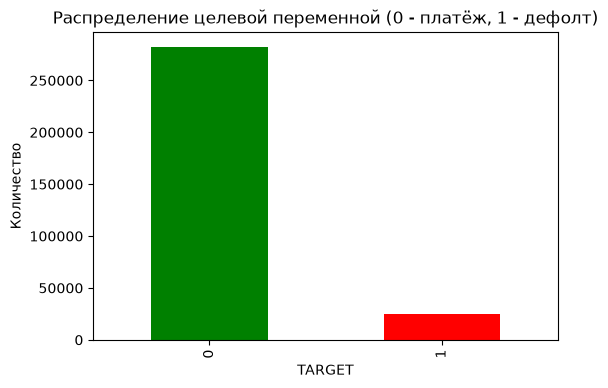

In [10]:
# Визуализация дисбаланса
print(f"\nБаланс классов:\n{df['TARGET'].value_counts()}")
print(f"Доля дефолтов: {df['TARGET'].mean():.2%}")

plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение целевой переменной (0 - платёж, 1 - дефолт)')
plt.xlabel('TARGET')
plt.ylabel('Количество')
plt.show()

## Обработка пропусков


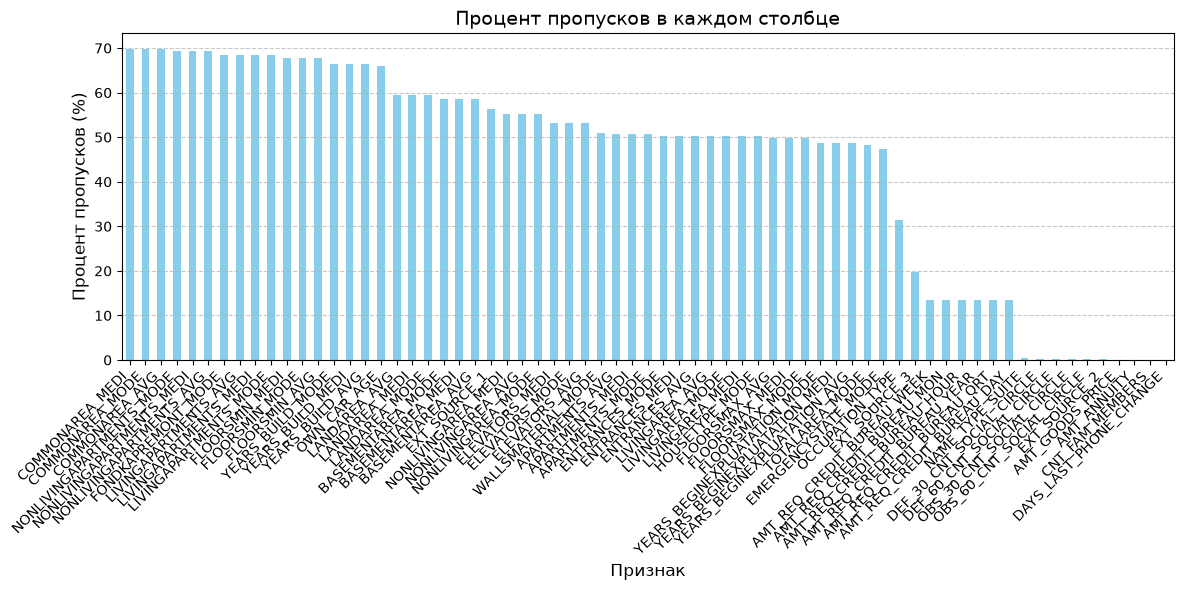

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)


plt.figure(figsize=(12, 6))
missing_percent.plot(kind='bar', color='skyblue')
plt.title('Процент пропусков в каждом столбце', fontsize=14)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Процент пропусков (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Теперь посмотрим на корреляцию между таргетом и столбцами, содержащими AVG, MEDI, MODE


NONLIVINGAPARTMENTS_MODE                 -0.001557
NONLIVINGAPARTMENTS_MEDI                 -0.002757
NONLIVINGAPARTMENTS_AVG                  -0.003176
YEARS_BEGINEXPLUATATION_MODE             -0.009036
YEARS_BEGINEXPLUATATION_AVG              -0.009728
YEARS_BEGINEXPLUATATION_MEDI             -0.009993
LANDAREA_MODE                            -0.010174
LANDAREA_AVG                             -0.010885
LANDAREA_MEDI                            -0.011256
NONLIVINGAREA_MODE                       -0.012711
NONLIVINGAREA_MEDI                       -0.013337
NONLIVINGAREA_AVG                        -0.013578
COMMONAREA_MODE                          -0.016340
ENTRANCES_MODE                           -0.017387
COMMONAREA_AVG                           -0.018550
COMMONAREA_MEDI                          -0.018573
ENTRANCES_MEDI                           -0.019025
ENTRANCES_AVG                            -0.019172
BASEMENTAREA_MODE                        -0.019952
YEARS_BUILD_MODE               

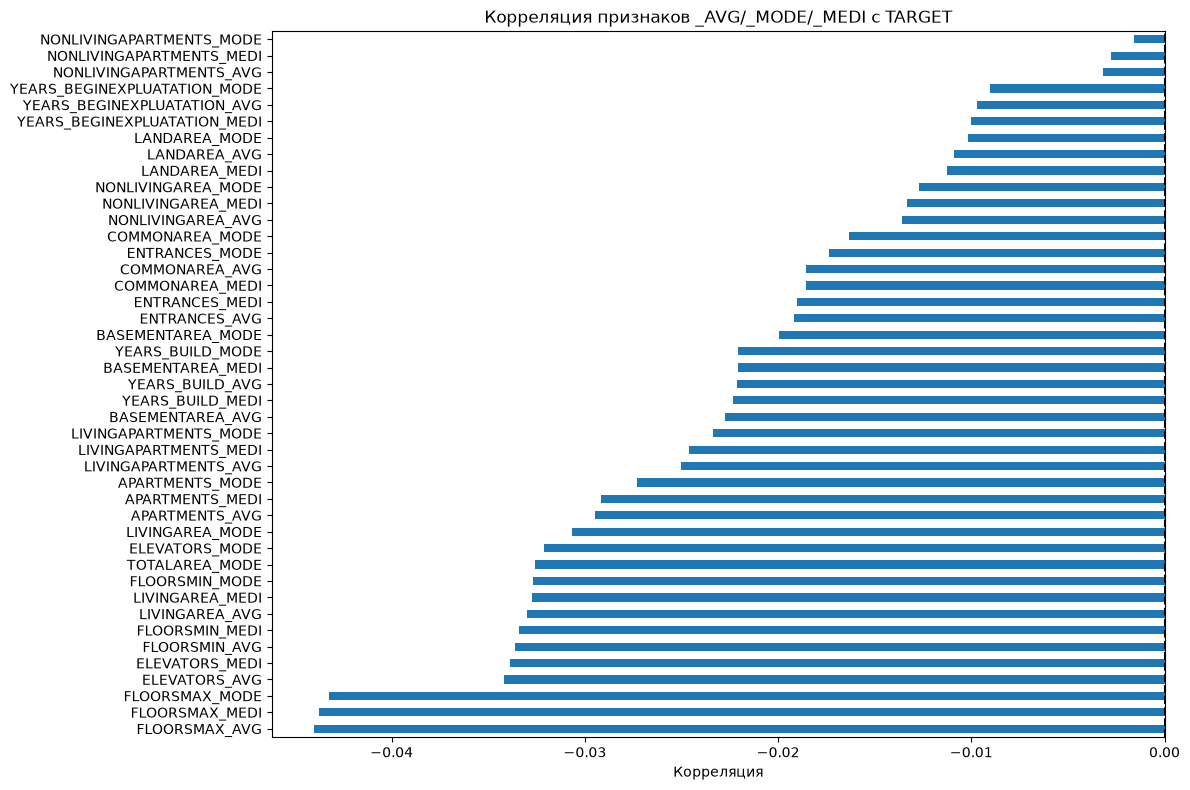

In [12]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# filtering _AVG, _MODE, _MEDI
avg_mode_medi = [col for col in numeric_cols if any(x in col for x in ['_AVG', '_MODE', '_MEDI'])]
# correlation with target
corr_avg_mode_medi = df[avg_mode_medi + ['TARGET']].corr()['TARGET'].sort_values(ascending=False)

for col, corr in corr_avg_mode_medi.items():
    if col != 'TARGET':
        print(f"{col:40s} {corr:.6f}")

plt.figure(figsize=(12, 8))
corr_avg_mode_medi.drop('TARGET').sort_values().plot(kind='barh')
plt.title('Корреляция признаков _AVG/_MODE/_MEDI с TARGET')
plt.xlabel('Корреляция')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


Получили, что корреляция у таргета и выбранных нами столбцов близка к нулю, то есть они по сути бесполезны, к тому же еще и имеют огромное количество пропусков

Общее число категориальных столбцов: 16
Число категориальных столбцов с пропусками: 6


C:\Users\volko\AppData\Local\Temp\ipykernel_14136\1087343647.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


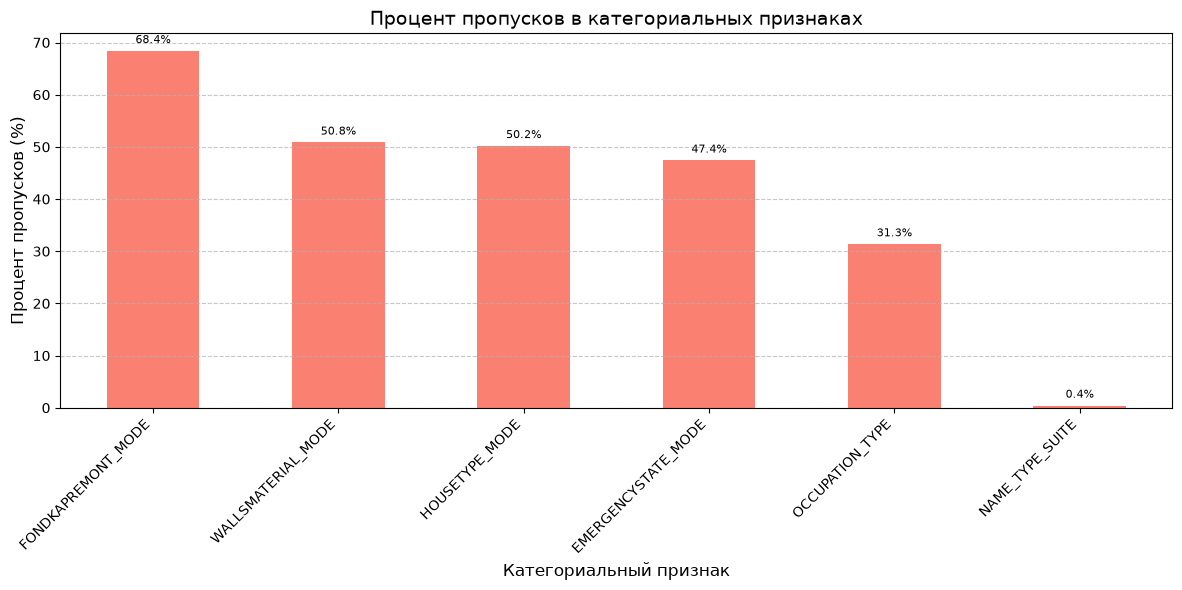

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
print('Общее число категориальных столбцов:', len(cat_cols))
print('Число категориальных столбцов с пропусками: 6')
missing_percent_cat = (df[cat_cols].isnull().sum() / len(df)) * 100
missing_percent_cat = missing_percent_cat[missing_percent_cat > 0].sort_values(ascending=False)

if len(missing_percent_cat) > 0:
    plt.figure(figsize=(12, 6))
    missing_percent_cat.plot(kind='bar', color='salmon')
    plt.title('Процент пропусков в категориальных признаках', fontsize=14)
    plt.xlabel('Категориальный признак', fontsize=12)
    plt.ylabel('Процент пропусков (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for i, v in enumerate(missing_percent_cat):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

### Первые 3 признака по количеству пропусков удалим в виду их неинформативности и специфичности, оставшиеся заполним 'Unknown'


In [14]:
cols_to_drop = ['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE']
df = df.drop(columns=cols_to_drop, errors='ignore')
df = df.drop(columns=avg_mode_medi, errors='ignore')
print(f"Удалены столбцы: {cols_to_drop}")

# processing all the rest categorical variables
cat_cols_to_keep = ['EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE', 'NAME_TYPE_SUITE']

for col in cat_cols_to_keep:
    df[col] = df[col].fillna('Unknown')

    if col == 'OCCUPATION_TYPE':
        df['OCCUPATION_UNKNOWN'] = (df['OCCUPATION_TYPE'] == 'Unknown').astype(int)

print(f"\nПроверка пропусков в категориальных колонках:")
print(df[cat_cols_to_keep].isnull().sum())

Удалены столбцы: ['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE']

Проверка пропусков в категориальных колонках:
EMERGENCYSTATE_MODE    0
OCCUPATION_TYPE        0
NAME_TYPE_SUITE        0
dtype: int64


### Чистим оставшиеся бесполезные числовые столбцы: различные флаги, которые лишь раздувают датасет и не несут особой информативности


In [15]:
cols_to_drop = ['SK_ID_CURR', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OWN_CAR_AGE']
doc_flags = [col for col in df.columns if col.startswith('FLAG_DOCUMENT_')]
cols_to_drop.extend(doc_flags)
df = df.drop(columns=cols_to_drop)
print(f"Удалено ID и флаги: {len(cols_to_drop)}")

# processing DAYS_EMPLOYED
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# filling the gaps for missing values ​​for important numerical features
cols_to_fill = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
for col in cols_to_fill:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"\nОсталось столбцов: {df.shape[1]}")
print(f"Осталось пропусков: {df.isnull().sum().sum()}")
print(f"Числовых столбцов: {len(df.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Категориальных: {len(df.select_dtypes(include=['object']).columns)}")

Удалено ID и флаги: 28

Осталось столбцов: 49
Осталось пропусков: 253201
Числовых столбцов: 36
Категориальных: 13


C:\Users\volko\AppData\Local\Temp\ipykernel_14136\1478422120.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Категориальных: {len(df.select_dtypes(include=['object']).columns)}")


## Далее рассмотрим распределения основных числовых характеристик.




Для того, чтоб определить, какие из них по-настоящему важны, рассмотрим их корреляцию с таргетом

In [16]:
# correlation of all numerical features with TARGET
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['TARGET'].abs().sort_values(ascending=False)

# displaying top 15
print("Топ-15 признаков по корреляции с TARGET")
for col, corr in correlations.head(20).items():
    if col != 'TARGET':
        print(f"{col:30s} {corr:.4f}")

Топ-15 признаков по корреляции с TARGET
EXT_SOURCE_2                   0.1603
EXT_SOURCE_3                   0.1559
EXT_SOURCE_1                   0.0989
DAYS_BIRTH                     0.0782
DAYS_EMPLOYED                  0.0634
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
REG_CITY_NOT_LIVE_CITY         0.0444
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE                0.0396
OCCUPATION_UNKNOWN             0.0387
REGION_POPULATION_RELATIVE     0.0372
LIVE_CITY_NOT_WORK_CITY        0.0325
DEF_30_CNT_SOCIAL_CIRCLE       0.0322
DEF_60_CNT_SOCIAL_CIRCLE       0.0313
AMT_CREDIT                     0.0304


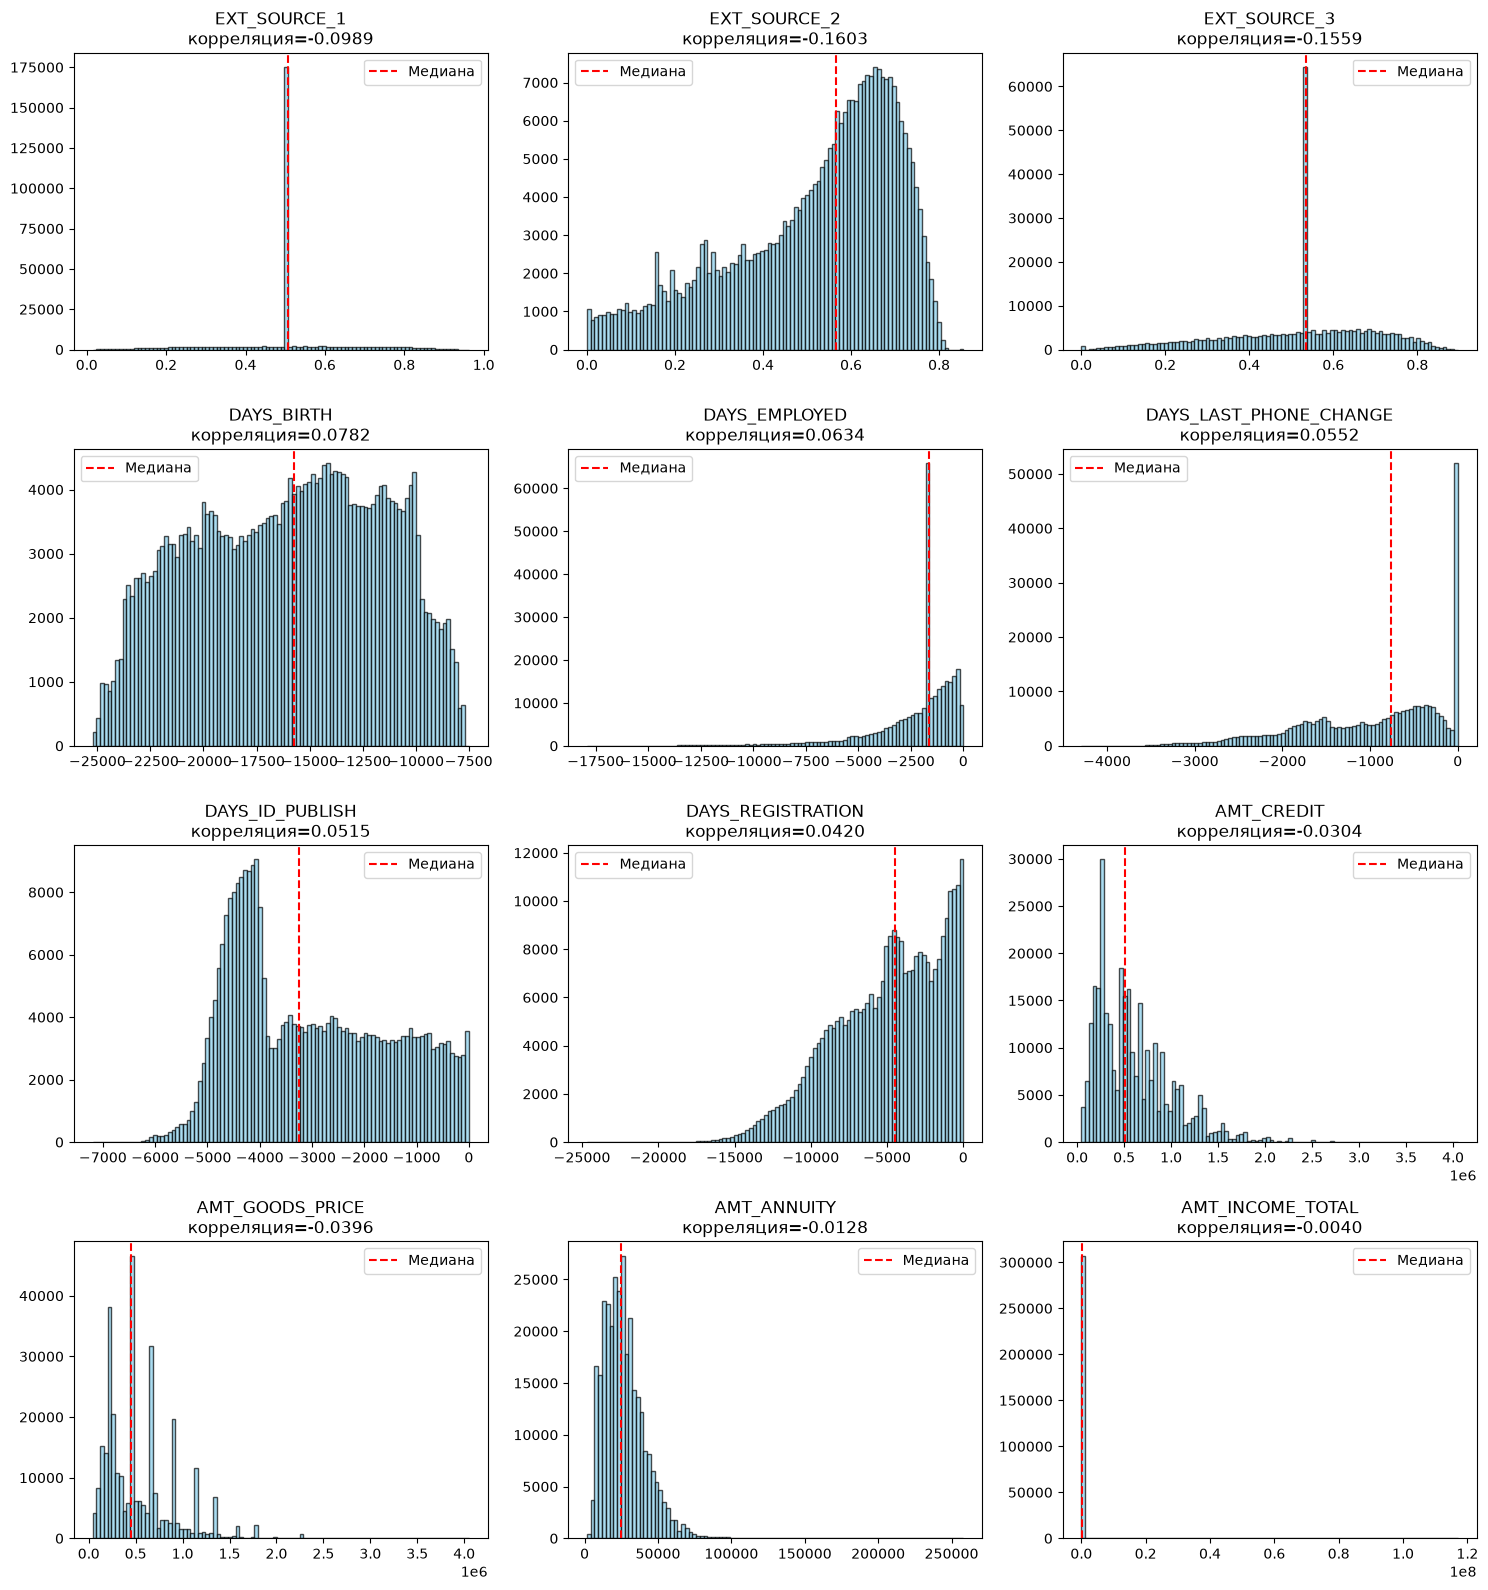

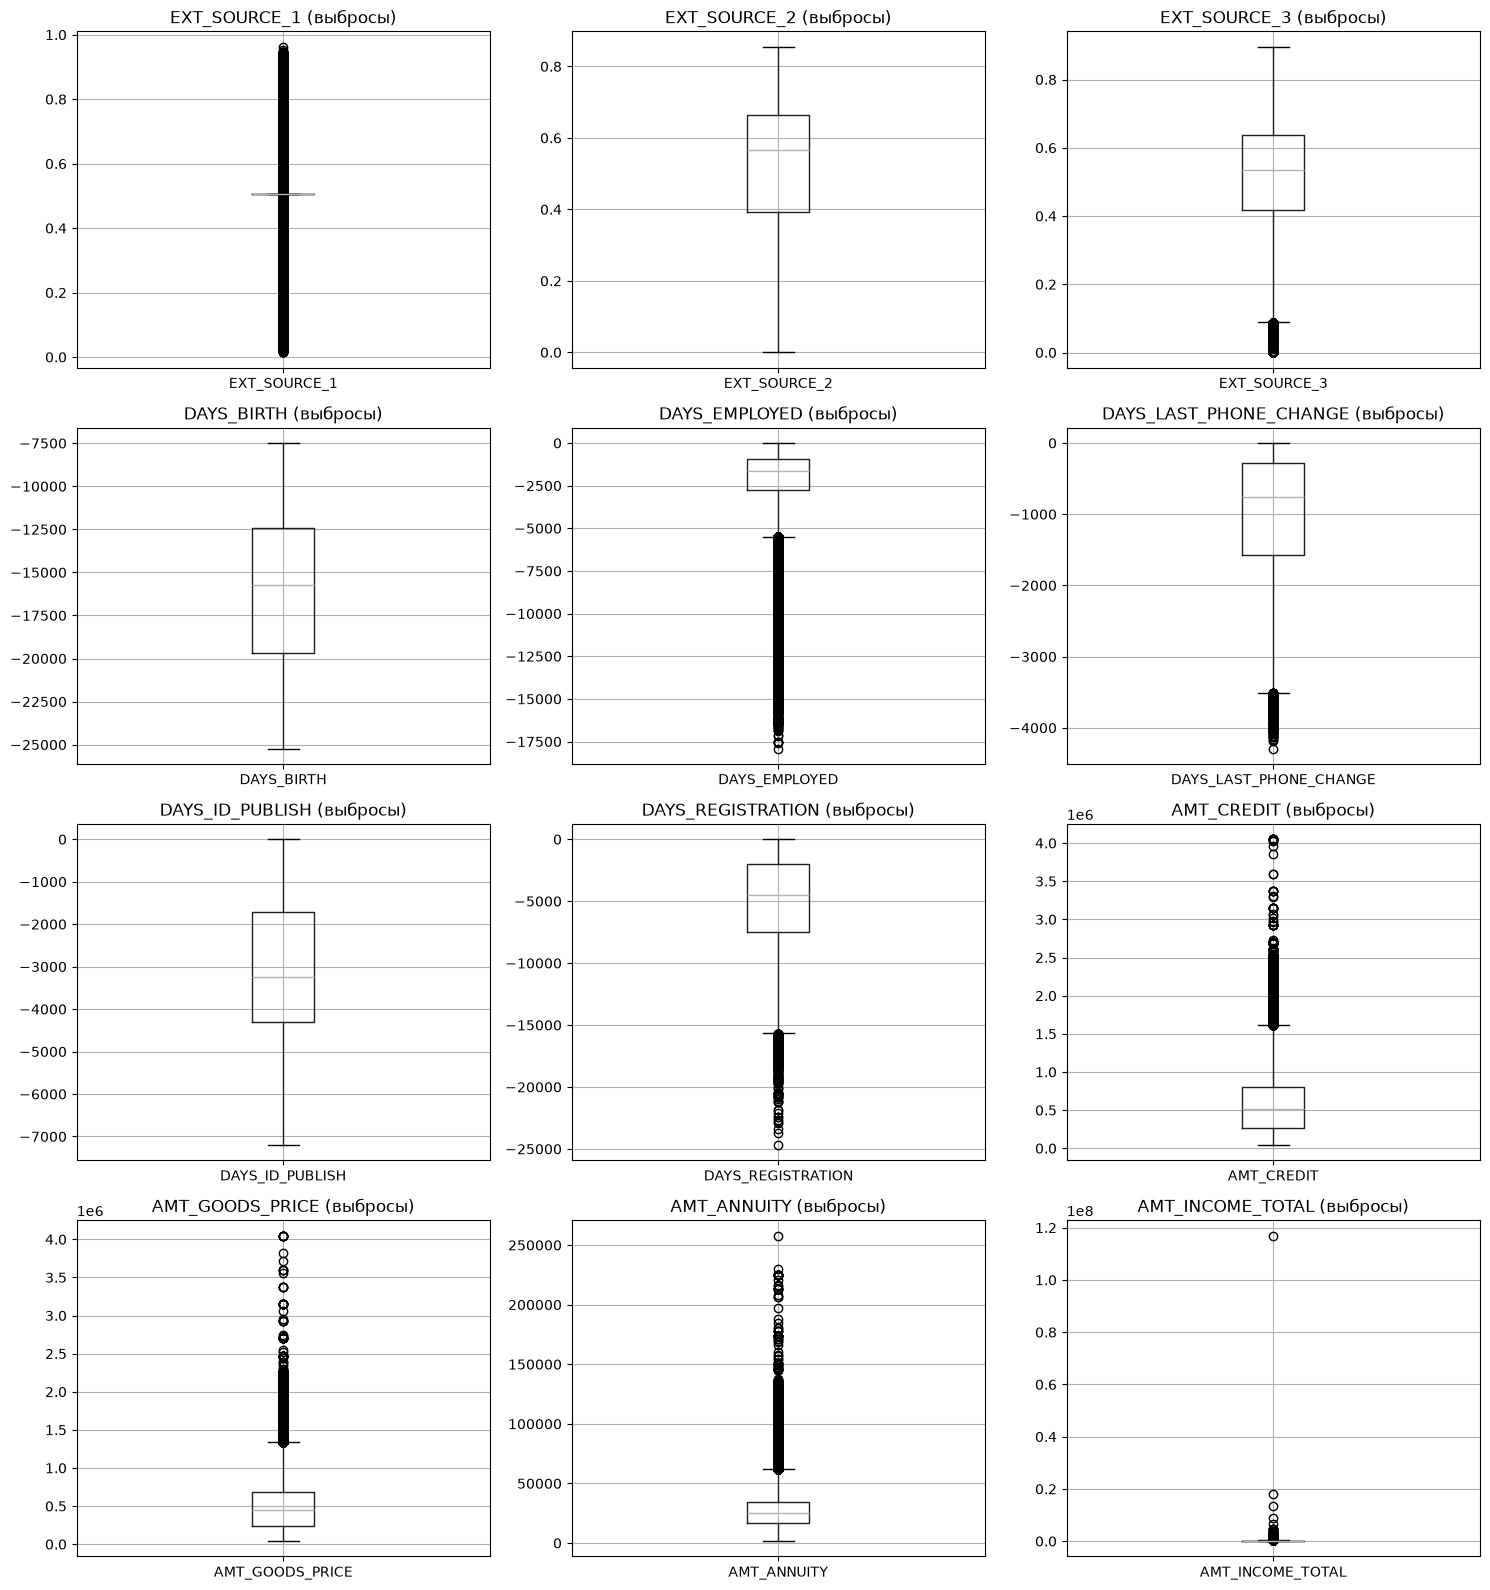

In [17]:
top_features = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',

    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH',
    'DAYS_REGISTRATION',

    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL'
]

n_cols = 3
n_rows = math.ceil(len(top_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(top_features):

    data = df[col].dropna()

    axes[i].hist(
        data,
        bins=100,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    corr = df[col].corr(df['TARGET'])

    axes[i].set_title(
        f'{col}\nкорреляция={corr:.4f}'
    )

    axes[i].axvline(
        data.median(),
        color='red',
        linestyle='--',
        label='Медиана'
    )

    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(top_features):
    if col in df.columns:
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'{col} (выбросы)')

plt.tight_layout()
plt.show()

Винсоризация выполнена
Созданы логарифмические признаки

Добавлены признаки:
AMT_CREDIT_LOG
AMT_GOODS_PRICE_LOG
AMT_ANNUITY_LOG
AMT_INCOME_TOTAL_LOG

Размер датасета: (307511, 53)


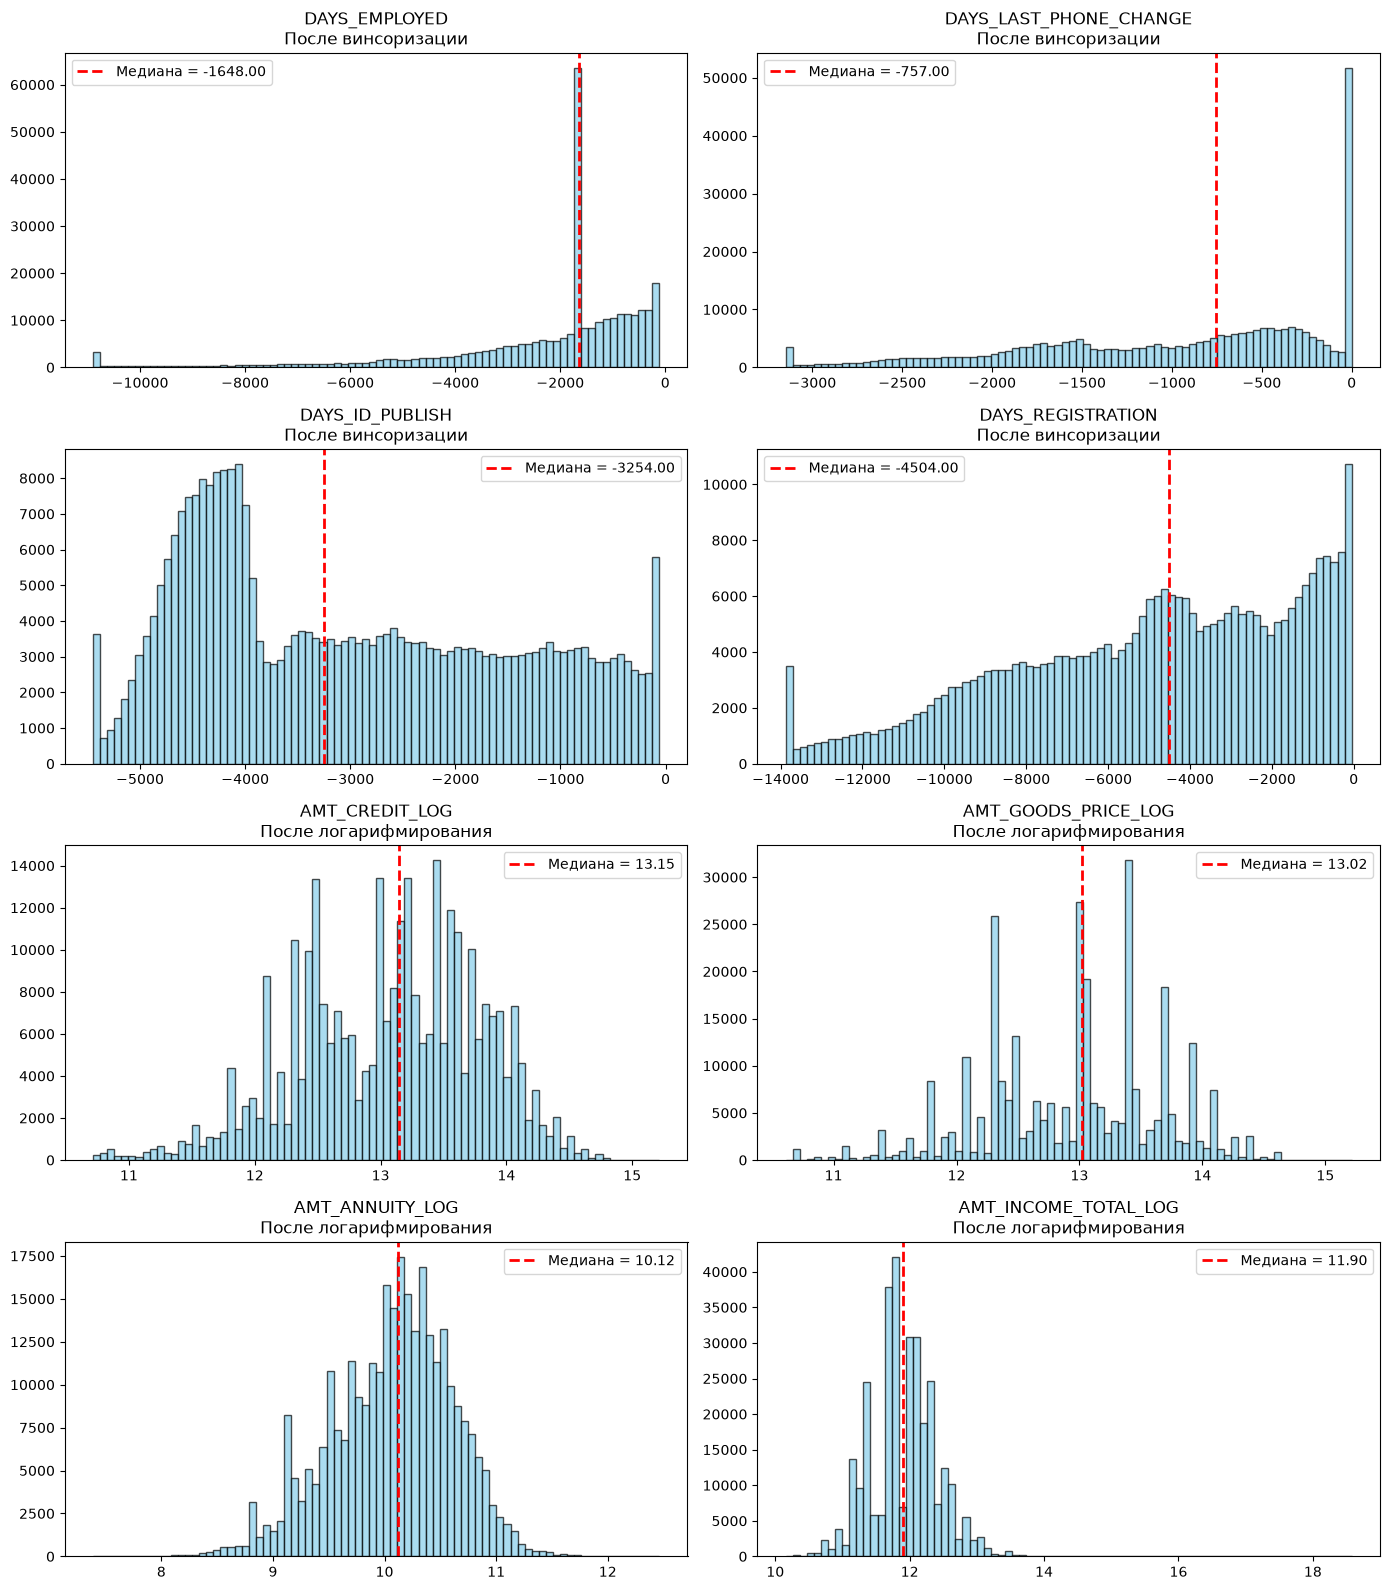

In [18]:
winsor_cols = [
    'DAYS_EMPLOYED',
    'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH',
    'DAYS_REGISTRATION'
]

for col in winsor_cols:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(
        lower=q01,
        upper=q99
    )
print("Винсоризация выполнена")


log_cols = [
    'AMT_CREDIT',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL'
]

for col in log_cols:
    df[f'{col}_LOG'] = np.log1p(df[col])
print("Созданы логарифмические признаки")


print("\nДобавлены признаки:")
for col in log_cols:
    print(f'{col}_LOG')
print(f'\nРазмер датасета: {df.shape}')


features_to_check = [
    ('DAYS_EMPLOYED', 'После винсоризации'),
    ('DAYS_LAST_PHONE_CHANGE', 'После винсоризации'),
    ('DAYS_ID_PUBLISH', 'После винсоризации'),
    ('DAYS_REGISTRATION', 'После винсоризации'),

    ('AMT_CREDIT_LOG', 'После логарифмирования'),
    ('AMT_GOODS_PRICE_LOG', 'После логарифмирования'),
    ('AMT_ANNUITY_LOG', 'После логарифмирования'),
    ('AMT_INCOME_TOTAL_LOG', 'После логарифмирования')
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, (col, title) in enumerate(features_to_check):
    data = df[col].dropna()

    axes[i].hist(
        data,
        bins=80,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    axes[i].axvline(
        data.median(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Медиана = {data.median():.2f}'
    )

    axes[i].set_title(f'{col}\n{title}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Генерация фичей


In [31]:
df['AGE'] = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365


# fin coefs
df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

# external scoring sources
df['EXT_SOURCE_MEAN'] = (
    df[['EXT_SOURCE_1',
        'EXT_SOURCE_2',
        'EXT_SOURCE_3']]
    .mean(axis=1)
)

df['EXT_SOURCE_PROD'] = (
    df['EXT_SOURCE_1'] *
    df['EXT_SOURCE_2'] *
    df['EXT_SOURCE_3']
)

# social environment
df['SOCIAL_DEF_RATIO_30'] = (
    df['DEF_30_CNT_SOCIAL_CIRCLE'] /
    (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
)

df['SOCIAL_DEF_RATIO_60'] = (
    df['DEF_60_CNT_SOCIAL_CIRCLE'] /
    (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
)

# ratio of length of service to age
df['EMPLOYMENT_RATIO'] = (
    df['DAYS_EMPLOYED'] /
    df['DAYS_BIRTH']
)


Посмотрим на корреляцию новых признаков

Корреляция новых фич с таргетом
               Feature  Correlation
5      EXT_SOURCE_MEAN     0.220840
6      EXT_SOURCE_PROD     0.189605
0                  AGE     0.078239
4      CREDIT_TO_GOODS     0.068474
1     EMPLOYMENT_YEARS     0.064069
9     EMPLOYMENT_RATIO     0.049372
7  SOCIAL_DEF_RATIO_30     0.032139
8  SOCIAL_DEF_RATIO_60     0.029870
3    ANNUITY_TO_INCOME     0.014268
2       DEBT_TO_INCOME     0.007727


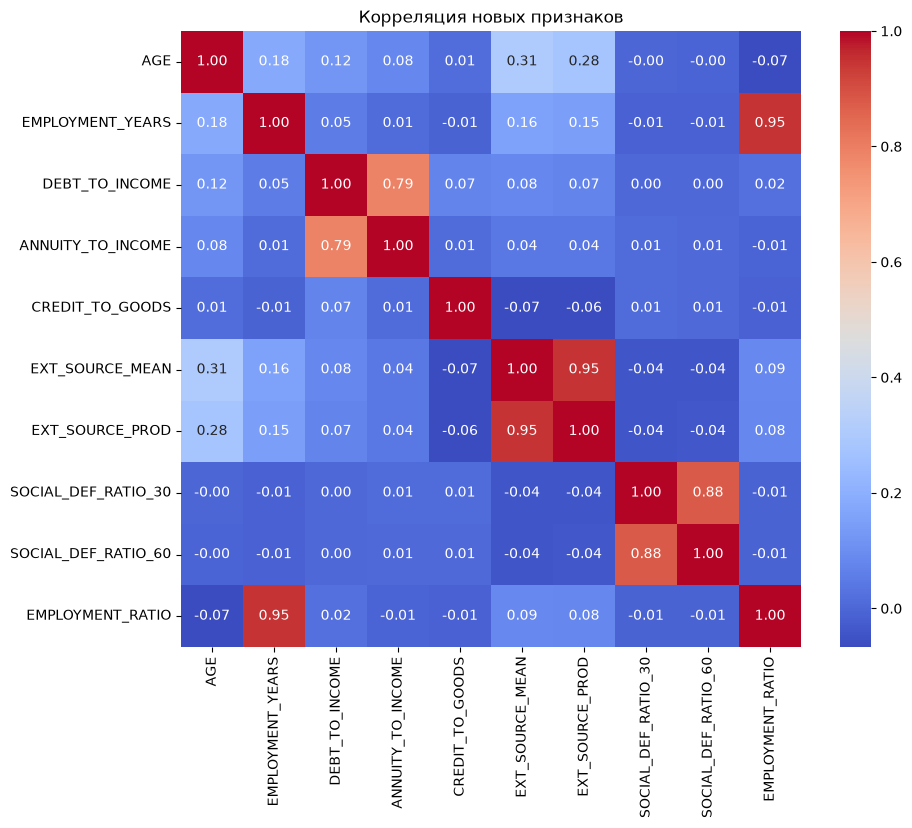

In [20]:
new_features = [
    'AGE',
    'EMPLOYMENT_YEARS',
    'DEBT_TO_INCOME',
    'ANNUITY_TO_INCOME',
    'CREDIT_TO_GOODS',
    'EXT_SOURCE_MEAN',
    'EXT_SOURCE_PROD',
    'SOCIAL_DEF_RATIO_30',
    'SOCIAL_DEF_RATIO_60',
    'EMPLOYMENT_RATIO'
]

corr_df = pd.DataFrame({
    'Feature': new_features,
    'Correlation': [
        abs(df[col].corr(df['TARGET']))
        for col in new_features
    ]
})

corr_df.sort_values(
    'Correlation',
    ascending=False,
    inplace=True
)

print('Корреляция новых фич с таргетом')
print(corr_df)

corr_matrix = df[new_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Корреляция новых признаков')
plt.show()

# ОБУЧЕНИЕ МОДЕЛЕЙ


In [32]:
# firstly we will check all remaining data for missing values
# if any are found, we will fill them with zeros or the median, since only the more or less informative features remain at this stage

print(df.shape)
print(df.isna().sum().sum())
print(df.dtypes.value_counts())

pd.DataFrame({
    'missing': df.isna().sum(),
    'percent': df.isna().mean() * 100
}).query('missing > 0').sort_values('missing', ascending=False)

(307511, 63)
0
float64    36
int64      14
str        13
Name: count, dtype: int64


,missing,percent


Заполним найденные пропуски в оставшихся данных

In [33]:
# credit bureau requests with nulls
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df[bureau_cols] = df[bureau_cols].fillna(0)


# social characteristics with median
social_cols = [
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE'
]

for col in social_cols:
    df[col] = df[col].fillna(df[col].median())


# residual omissions with mediana
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(
    df['CNT_FAM_MEMBERS'].median()
)

df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].fillna(
    df['DAYS_LAST_PHONE_CHANGE'].median()
)


# calculating new social coefs
df['SOCIAL_DEF_RATIO_30'] = (
    df['DEF_30_CNT_SOCIAL_CIRCLE']
    /
    (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
)

df['SOCIAL_DEF_RATIO_60'] = (
    df['DEF_60_CNT_SOCIAL_CIRCLE']
    /
    (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)
)

missing_total = df.isna().sum().sum()

print(f'Осталось пропусков: {missing_total:,}')

if missing_total == 0:
    print('Датасет полностью готов к моделированию')
else:
    print('Остались пропуски')
    print(df.isna().sum()[df.isna().sum() > 0])

Осталось пропусков: 0
Датасет полностью готов к моделированию


In [34]:
df_model = pd.get_dummies(df, drop_first=True)
X = df_model.drop('TARGET', axis=1)
y = df_model['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=3
)

print(X_train.shape)
print(X_test.shape)
def evaluate_model(model, X_test, y_test, model_name):

    # predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    # displaying metrics
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(ax=ax)
    ax.set_title(f'{model_name}\nConfusion Matrix')
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'ROC-AUC = {roc_auc:.4f}'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        '--'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name}\nROC Curve')

    plt.legend()
    plt.grid(True)

    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc
    }

(246008, 165)
(61503, 165)


In [24]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=3
)

print("train:", X_train_part.shape)
print("validation:", X_val.shape)
print("test:", X_test.shape)

train: (196806, 165)
validation: (49202, 165)
test: (61503, 165)


## Логистическая регрессия


c:\PythonPath\Credit-Scoring-Bot\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression
Accuracy : 0.6855
Precision: 0.1613
Recall   : 0.6896
F1-score : 0.2614
ROC-AUC  : 0.7512
PR-AUC : 0.2259


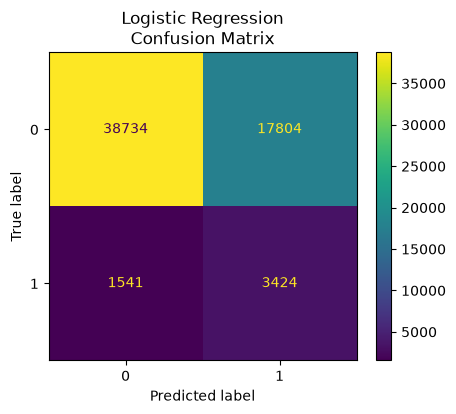

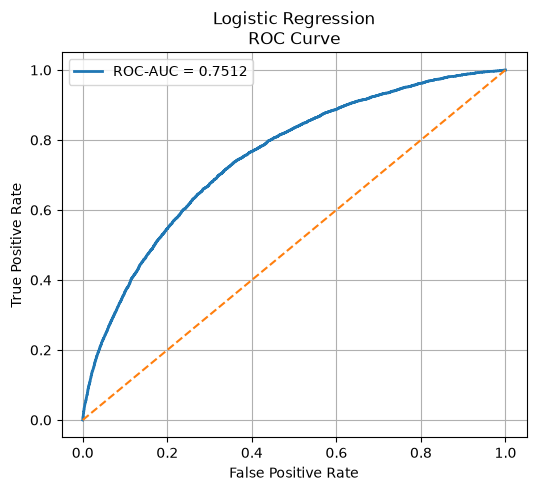

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    random_state=3,
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)
log_reg_result = evaluate_model(
    log_reg,
    X_test_scaled,
    y_test,
    'Logistic Regression'
)

## Random Forest


Random Forest
Accuracy : 0.7039
Precision: 0.1655
Recall   : 0.6602
F1-score : 0.2647
ROC-AUC  : 0.7497
PR-AUC : 0.2291


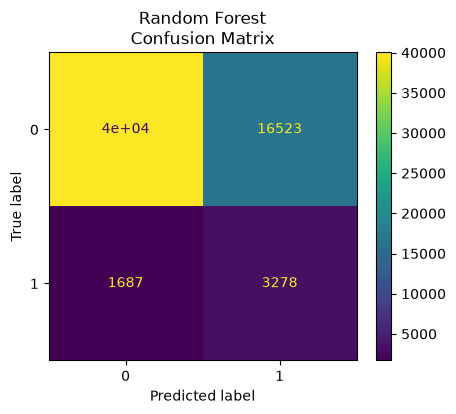

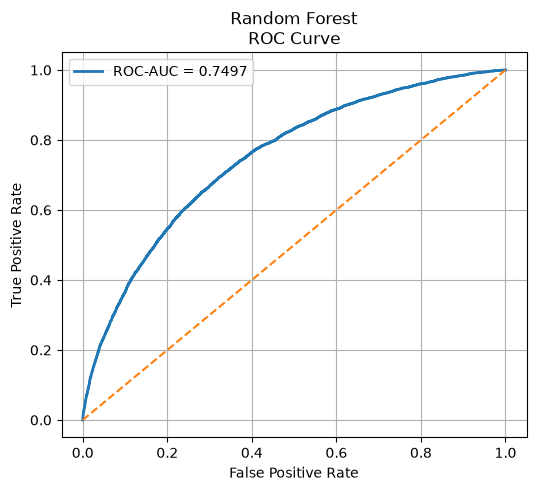

In [26]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=3,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_result = evaluate_model(
    rf,
    X_test,
    y_test,
    'Random Forest'
)

## XGBoost

XGBoost
Accuracy : 0.7250
Precision: 0.1774
Recall   : 0.6614
F1-score : 0.2797
ROC-AUC  : 0.7640
PR-AUC : 0.2492


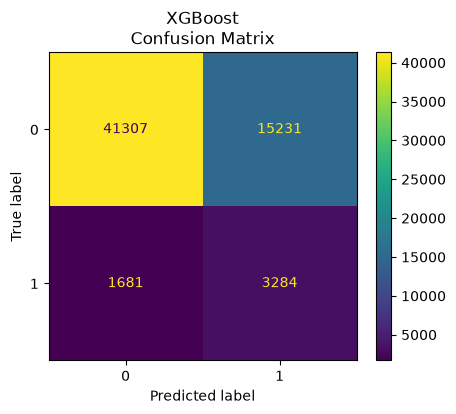

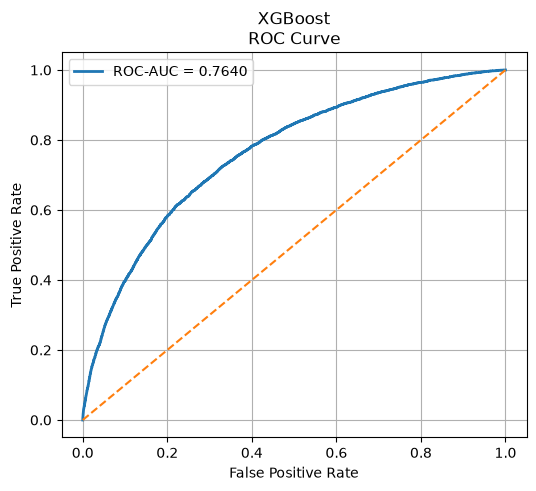

In [27]:
scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=3,
    eval_metric='logloss',
)

xgb.fit(X_train, y_train)
xgb_result = evaluate_model(
    xgb,
    X_test,
    y_test,
    'XGBoost'
)

## LightGBM

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6607
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

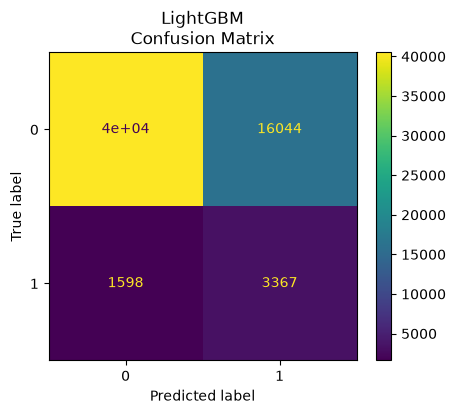

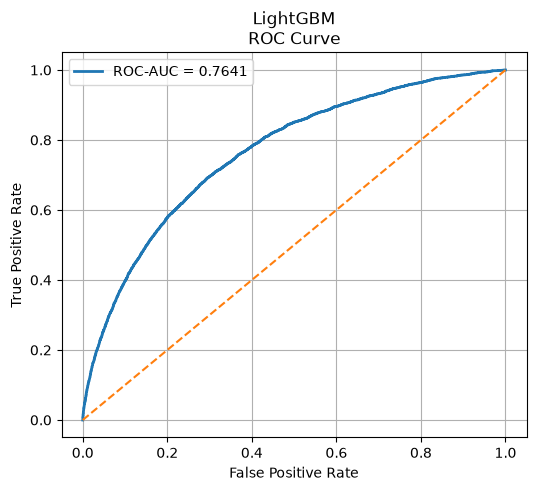

In [28]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_test.columns
]

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=3
)

lgbm.fit(X_train, y_train)
lgbm_result = evaluate_model(
    lgbm,
    X_test,
    y_test,
    'LightGBM'
)

## CatBoost

CatBoost
Accuracy : 0.9199
Precision: 0.6211
Recall   : 0.0201
F1-score : 0.0390
ROC-AUC  : 0.7654
PR-AUC : 0.2532


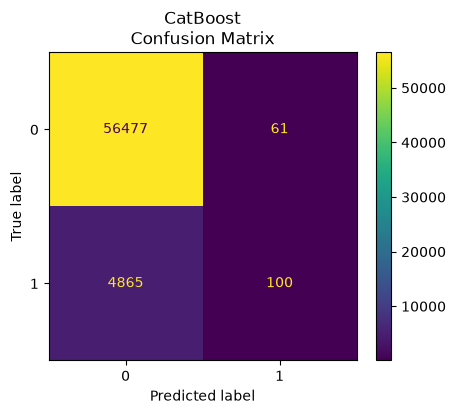

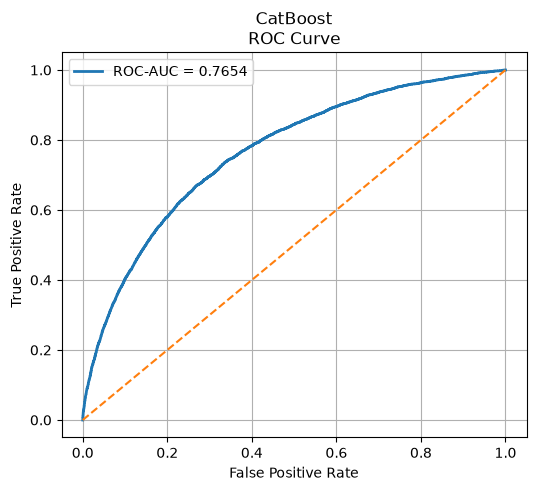

In [35]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=3,
    verbose=0
)

cat.fit(X_train_part, y_train_part)

cat_result = evaluate_model(
    cat,
    X_test,
    y_test,
    'CatBoost'
)

# y_val_proba = cat.predict_proba(X_val)[:, 1]

# thresholds = np.arange(0.05, 0.51, 0.01)
# results = []

# for threshold in thresholds:
#     y_val_pred = (y_val_proba >= threshold).astype(int)

#     results.append({
#         'threshold': threshold,
#         'precision': precision_score(y_val, y_val_pred, zero_division=0),
#         'recall': recall_score(y_val, y_val_pred, zero_division=0),
#         'f1': f1_score(y_val, y_val_pred, zero_division=0)
#     })

# threshold_results = pd.DataFrame(results)
# threshold_results.sort_values('f1', ascending=False).head(10)

## Подбор порога по стоимости ошибок

In [36]:
# threshold selection based on the cost of errors
# fn - missed defaulter (we lose part of the loan), fp - rejected good client (we lose the margin)
# only the relative cost matters, so fp cost is fixed to 1 and fn cost = ratio

y_val_proba = cat.predict_proba(X_val)[:, 1]

# calibration sanity check: for a well calibrated model these two numbers are close
print(f"mean predicted probability: {y_val_proba.mean():.4f}")
print(f"actual default rate: {y_val.mean():.4f}")

thresholds = np.arange(0.01, 0.51, 0.01)
cost_ratios = [2, 3, 5, 7, 10]
results = []

for ratio in cost_ratios:
    costs = []

    for threshold in thresholds:
        y_val_pred = (y_val_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        costs.append(fp + ratio * fn)

    best_threshold = thresholds[np.argmin(costs)]
    y_val_pred = (y_val_proba >= best_threshold).astype(int)

    results.append({
        'fn_to_fp_cost': ratio,
        'best_threshold': best_threshold,
        'theory_threshold': 1 / (1 + ratio),
        'precision': precision_score(y_val, y_val_pred, zero_division=0),
        'recall': recall_score(y_val, y_val_pred, zero_division=0),
        'rejected_share': y_val_pred.mean()
    })

cost_results = pd.DataFrame(results)
cost_results

mean predicted probability: 0.0798
actual default rate: 0.0807


,fn_to_fp_cost,best_threshold,theory_threshold,precision,recall,rejected_share
0,2,0.33,0.333333,0.437430,0.097684,0.018028
1,3,0.27,0.250000,0.369539,0.153323,0.033495
2,5,0.15,0.166667,0.246480,0.409869,0.134243
3,7,0.13,0.125000,0.222471,0.475579,0.172574
4,10,0.10,0.090909,0.188876,0.591641,0.252876


In [37]:
# final threshold from the business cost ratio
# the model is well calibrated, so we take the theoretical threshold instead of the one tuned on validation
fn_to_fp_cost = 5
final_threshold = 1 / (1 + fn_to_fp_cost)

print(f"final threshold: {final_threshold:.4f}")

# checking the threshold on validation and test: the numbers should be close
check_results = []

for sample_name, X_sample, y_sample in [
    ('validation', X_val, y_val),
    ('test', X_test, y_test)
]:
    y_sample_proba = cat.predict_proba(X_sample)[:, 1]
    y_sample_pred = (y_sample_proba >= final_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_sample, y_sample_pred).ravel()

    check_results.append({
        'sample': sample_name,
        'precision': precision_score(y_sample, y_sample_pred, zero_division=0),
        'recall': recall_score(y_sample, y_sample_pred, zero_division=0),
        'rejected_share': y_sample_pred.mean(),
        'cost_per_100': (fp + fn_to_fp_cost * fn) / len(y_sample) * 100,
        'mean_proba': y_sample_proba.mean(),
        'default_rate': y_sample.mean()
    })

# detailed report on test
y_test_pred = (cat.predict_proba(X_test)[:, 1] >= final_threshold).astype(int)
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

pd.DataFrame(check_results)

final threshold: 0.1667
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     56538
           1       0.27      0.37      0.31      4965

    accuracy                           0.87     61503
   macro avg       0.61      0.64      0.62     61503
weighted avg       0.89      0.87      0.88     61503

[[51577  4961]
 [ 3112  1853]]


,sample,precision,recall,rejected_share,cost_per_100,mean_proba,default_rate
0,validation,0.256542,0.352971,0.111073,34.374619,0.079829,0.080728
1,test,0.271940,0.373212,0.110791,33.365852,0.080116,0.080728


## Организация файлов для бота



In [38]:
# saving a consistent set of files for the bot: model, feature lists and threshold
# cat was trained on X_train_part, whose columns keep the original get_dummies names -
# exactly the names the bot gets from pd.get_dummies at inference time
models_dir = '../models'

cat.save_model(os.path.join(models_dir, 'catboost_model.cbm'))
joblib.dump(list(X_train_part.columns), os.path.join(models_dir, 'model_features.joblib'))

raw_features = [col for col in df.columns if col != 'TARGET']
joblib.dump(raw_features, os.path.join(models_dir, 'raw_features.joblib'))

joblib.dump(final_threshold, os.path.join(models_dir, 'threshold.joblib'))

print(f"saved to: {os.path.abspath(models_dir)}")
print(f"model features: {len(X_train_part.columns)}")
print(f"raw features: {len(raw_features)}")
print(f"threshold: {final_threshold:.4f}")

saved to: c:\PythonPath\Credit-Scoring-Bot\models
model features: 165
raw features: 62
threshold: 0.1667


In [ ]:
# saving best model
# cat.save_model("catboost_model.cbm")

# joblib.dump(list(X_train.columns), "model_features.joblib")

# raw_features = [col for col in df.columns if col != "TARGET"]
# joblib.dump(raw_features, "raw_features.joblib")

# # saving an example of a valid login for the tg bot
# example_input = df.drop("TARGET", axis=1).iloc[0].to_dict()

# with open("example_input.json", "w", encoding="utf-8") as f:
#     json.dump(example_input, f, ensure_ascii=False, indent=4)

# # saving csv example
# test_clients = df.drop("TARGET", axis=1).head(10)
# test_clients.to_csv("test_clients.csv", index=False)

# print("Модель и служебные файлы сохранены")